In [58]:
import os 
import re
import umap 
import random
import numpy as np            
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from utils import*

In [2]:
results_folder = '/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/cgmvae_Dtarget0.98_newdata'
dataset_abbrev = ['Geno', 'Physio']
epoch = 40000
latent_dim = 10
random_seed = 10
hues = ['Encoder', 'Bin', 'Diet']

In [3]:
latent_space_geno = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_physio = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[1]}.csv'), index_col=False)
latent_space_comb = pd.concat([latent_space_geno, latent_space_physio])
latent_space_comb = latent_space_comb.reset_index(drop=True)

In [4]:
# load in prior samples
all_samples = []
for dataset in dataset_abbrev: 
    samples = pd.read_csv(os.path.join(results_folder, f'gmm_samples_{dataset}encoder.csv'))
    all_samples.append(samples)

In [5]:
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,Label,Diet,MouseID,Bin,CFM,Lifespan,Encoder
0,-1.058235,-1.059640,-1.689328,-1.293178,-1.309534,-1.261021,-1.465681,-1.248967,-0.997422,-1.158702,0,1D,DO-1D-3001,0,-1.790642,-0.621813,Geno
1,-2.763032,-2.423202,-2.544273,-2.548911,-2.646951,-2.799907,-2.815710,-2.569672,-2.656734,-2.616383,3,1D,DO-1D-3003,3,1.537107,-0.453265,Geno
2,-1.688613,-1.795856,-1.423639,-1.755662,-2.260169,-1.909375,-2.053635,-1.902371,-2.290421,-2.148566,1,1D,DO-1D-3010,1,-0.349890,0.900743,Geno
3,-1.025383,-0.700485,-1.505229,-1.337838,-0.791726,-1.254881,-1.401239,-1.230525,-0.975679,-1.238455,0,1D,DO-1D-3011,0,-0.942337,0.204075,Geno
4,-1.098031,-1.011956,-1.745282,-1.325441,-1.154122,-1.187761,-1.408870,-1.216121,-1.071388,-1.126669,0,1D,DO-1D-3013,0,-1.546032,-1.093750,Geno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,-0.883939,-0.539063,-1.603064,-1.349177,-1.183072,-1.226967,-1.320899,-1.314552,-1.756818,-1.080620,0,AL,DO-AL-0186,0,-1.003389,-1.520740,Physio
998,-1.049017,-1.056834,-1.467957,-1.297724,-1.121857,-1.190668,-1.360431,-1.311003,-0.986006,-1.164197,0,AL,DO-AL-0188,0,-1.088943,-0.183587,Physio
999,-1.662593,-1.454085,-1.729315,-1.615838,-1.880672,-0.896809,-1.853468,-1.278368,-1.005560,-0.751768,1,AL,DO-AL-0191,1,-0.831881,-0.975766,Physio
1000,-1.789689,-1.811422,-1.490680,-1.584498,-2.195249,-1.950985,-1.883149,-1.836748,-1.609938,-1.811750,1,1D,DO-1D-3083,1,-0.576425,0.063618,Physio


In [6]:
# plot the encoder distributions and corresponding priors
# for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
#     fig, ax = plt.subplots(1, 2, figsize=(12, 3))
#     sns.kdeplot(data=latent_space_comb[[column, 'Encoder']], x=column, hue='Encoder', fill=True, bw_adjust=1, ax=ax[0])
#     ax[0].set_title(column)
#     prior_col1 = all_samples[0].columns[i]
#     sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
#     current_colors = sns.color_palette().as_hex()
#     prior_col2 = all_samples[1].columns[i]
#     sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
#     ax[1].set_title(f'{column} prior distribution')

In [7]:
# plot the latent space kde of each resilience bin and corresponding priors
# cmap1 = cm.get_cmap('gist_heat')
# cmap2 = cm.get_cmap('Blues')
# custom_palette = {0: cmap1(0.5), 1: cmap1(0.85), 2: cmap2(0.4), 3: cmap2(0.99)}

# for i, column in enumerate(latent_space_comb.columns[:latent_dim]):

#     fig, ax = plt.subplots(1, 2, figsize=(12, 3))
#     sns.kdeplot(data=latent_space_comb[[column, 'Bin']], x=column, hue='Bin', fill=True, bw_adjust=3, ax=ax[0])
#     ax[0].set_title(column)
#     prior_col1 = all_samples[0].columns[i]
#     sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
#     prior_col2 = all_samples[1].columns[i]
#     sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
#     ax[1].set_title(f'{column} prior distribution')

In [8]:
# # plot individual latent spaces for each encoder colored by resilience bin and corresponsing priors 
# latent_space_comb['bin_enc'] = latent_space_comb['Bin'].astype(str) + '_' +  latent_space_comb['Encoder']
# for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
#     fig, ax = plt.subplots(1, 3, figsize=(15, 3))
#     #palette_geno = {'0_geno': cmap1(0.5), '1_geno': cmap1(0.85), '2_geno': cmap2(0.4), '3_geno': cmap2(0.99)}
#     geno = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[0])]
#     sns.kdeplot(data=geno[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[0])
#     ax[0].set_title(column)
#     #palette_physio = {'0_physio': cmap1(0.5), '1_physio': cmap1(0.85), '2_physio': cmap2(0.4), '3_physio': cmap2(0.99)}
#     physio = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[1])]
#     sns.kdeplot(data=physio[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[1])
#     ax[1].set_title(column)
#     prior_col1 = all_samples[0].columns[i]
#     sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
#     prior_col2 = all_samples[1].columns[i]
#     sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
#     ax[2].set_title(f'{column} prior distribution')

Look at phenotypic projection

In [9]:
d_target = 1
temperature = 0.181

/tmp/ipykernel_613215/3067088160.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_613215/3067088160.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


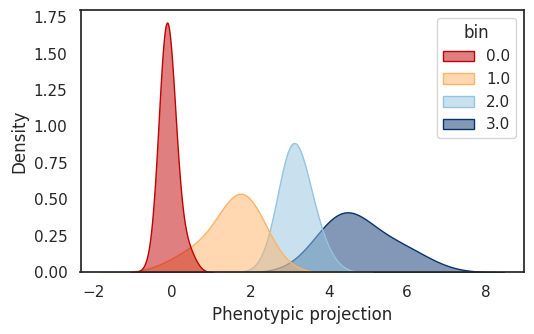

In [10]:
proj_points, overall_overlap, overlap_vals, overall_corr, corr_vals, sus, res = get_osd_from_latents_torch_new(torch.tensor(latent_space_comb.iloc[:, :latent_dim].values), latent_space_comb['Bin'].to_numpy(), torch.tensor(latent_space_comb['CFM']), d_target, temperature, state='eval')
proj_df = pd.DataFrame(proj_points, columns=['value', 'bin'])
# plot phenotypic projection
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
legend_labels = ['Strong susceptible', 'Weak susceptible', 'Weak resilient', 'Strong resilient']
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=proj_df, x='value',hue="bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
if not ax.legend_:
    plt.legend(title="bin",labels=proj_df["bin"].unique(),bbox_to_anchor=(1.05, 1))
plt.title("")
plt.xlabel('Phenotypic projection')
#plt.title(f'Overlap: {overall_overlap}, Correlation: {overall_corr}')
plt.tight_layout()
plt.show()

In [11]:
# finding the phenotypic projection the original way 
def project_row(row):
    coords = row[coord_cols].values
    proj, dist = line_coordinates_euclidean(sus, res, coords)
    return pd.Series({'Projected': proj,'Signed_Distance': dist})
coord_cols = latent_space_comb.iloc[:, :latent_dim].columns
sus = latent_space_comb.iloc[latent_space_comb['CFM'].nsmallest(1000).index, :latent_dim].apply(np.mean, axis=0).values
res = latent_space_comb.iloc[latent_space_comb['CFM'].nlargest(1000).index, :latent_dim].apply(np.mean, axis=0).values

projections = latent_space_comb.apply(project_row, axis=1)

df_pp = pd.concat([
    latent_space_comb.reset_index(drop=True),
    pd.DataFrame(projections['Projected'].tolist(), columns=[f'Proj_{i+1}' for i in range(10)]),
    projections[['Signed_Distance']]], axis=1)
df_pp.rename(columns={df_pp.columns[-1]: 'PP'}, inplace=True)

/tmp/ipykernel_613215/4287985014.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_613215/4287985014.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


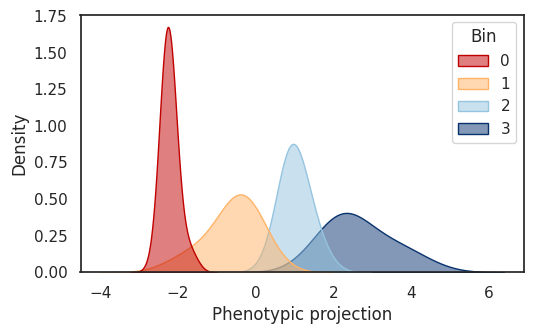

In [12]:
sns.set(style="white")
import matplotlib.cm as cm
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=df_pp,x='PP',hue="Bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
plt.title("")
plt.xlabel('Phenotypic projection')
plt.tight_layout()
plt.show()

Calculate individual phenotypic projection for each encoder

In [13]:
# calculate for geno encoder 
geno_coord_cols = latent_space_geno.iloc[:, :latent_dim].columns
sus_geno = latent_space_geno.iloc[latent_space_geno['CFM'].nsmallest(1000).index, :latent_dim].apply(np.mean, axis=0).values
res_geno = latent_space_geno.iloc[latent_space_geno['CFM'].nlargest(1000).index, :latent_dim].apply(np.mean, axis=0).values

projections = latent_space_geno.apply(project_row, axis=1)

df_geno_pp = pd.concat([
    latent_space_geno.reset_index(drop=True),
    pd.DataFrame(projections['Projected'].tolist(), columns=[f'Proj_{i+1}' for i in range(10)]),
    projections[['Signed_Distance']]], axis=1)
df_geno_pp.rename(columns={df_geno_pp.columns[-1]: 'PP'}, inplace=True)

/tmp/ipykernel_613215/619901944.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_613215/619901944.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


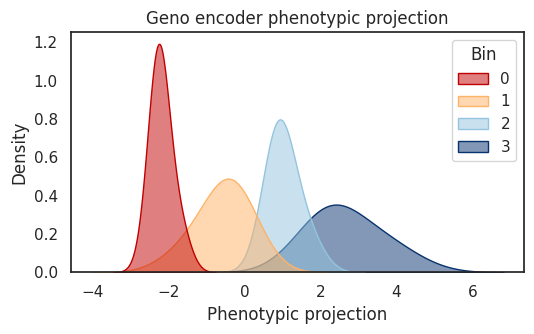

In [14]:
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=df_geno_pp,x='PP',hue="Bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
plt.title("Geno encoder phenotypic projection")
plt.xlabel('Phenotypic projection')
plt.tight_layout()
plt.show()

In [15]:
# calculate for geno encoder 
physio_coord_cols = latent_space_physio.iloc[:, :latent_dim].columns
sus_physio = latent_space_physio.iloc[latent_space_physio['CFM'].nsmallest(1000).index, :latent_dim].apply(np.mean, axis=0).values
res_physio = latent_space_physio.iloc[latent_space_physio['CFM'].nlargest(1000).index, :latent_dim].apply(np.mean, axis=0).values

projections = latent_space_physio.apply(project_row, axis=1)

df_physio_pp = pd.concat([
    latent_space_physio.reset_index(drop=True),
    pd.DataFrame(projections['Projected'].tolist(), columns=[f'Proj_{i+1}' for i in range(10)]),
    projections[['Signed_Distance']]], axis=1)
df_physio_pp.rename(columns={df_physio_pp.columns[-1]: 'PP'}, inplace=True)

/tmp/ipykernel_613215/935168173.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_613215/935168173.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


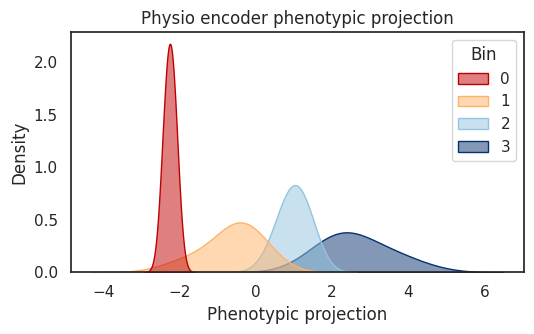

In [16]:
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=df_physio_pp,x='PP',hue="Bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
plt.title("Physio encoder phenotypic projection")
plt.xlabel('Phenotypic projection')
plt.tight_layout()
plt.show()

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


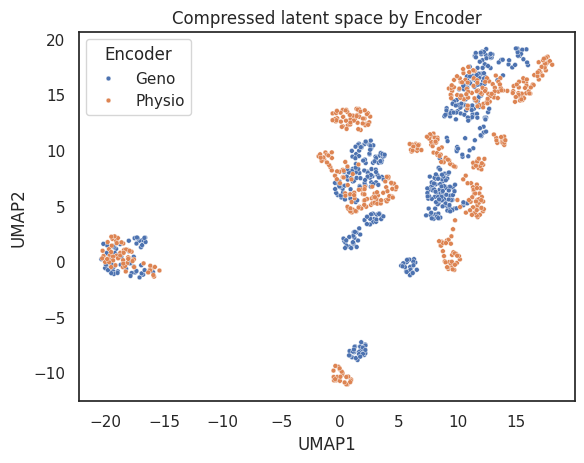

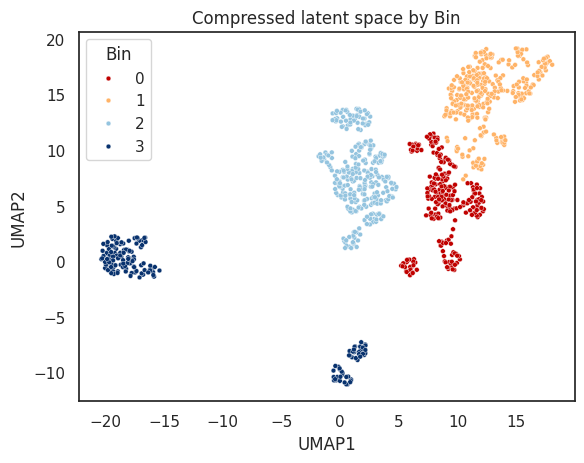

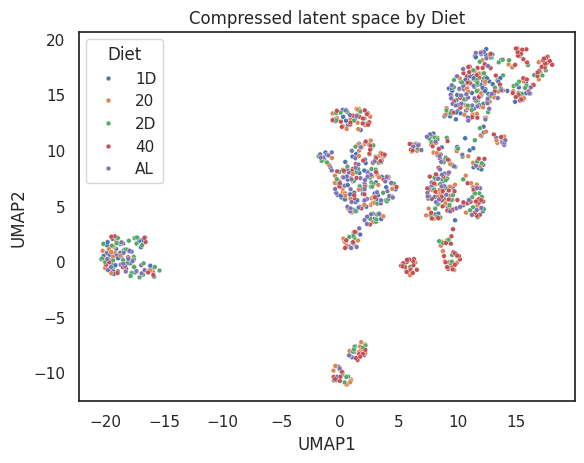

In [17]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(latent_space_comb.iloc[:, :latent_dim])
# generate embedding dataframe from compressed representation
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
embedding_df.to_csv(os.path.join(results_folder, 'latent_umap_embeddings.csv')) # save embedding 
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]
# plot umap colored by each of the hues
for hue in hues: 
    plt.figure()
    if hue == 'Bin':
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12, palette=custom_palette)
    else: 
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

In [18]:
endpoints = pd.read_csv(os.path.join(results_folder, 'endpoints.csv'))
endpoints

,0,1,2,3,4,5,6,7,8,9
0,-1.058147,-1.042693,-1.580716,-1.381991,-1.196510,-1.331030,-1.417179,-1.486114,-1.086401,-1.299687
1,-2.940998,-2.647557,-2.738815,-2.662738,-2.765101,-2.998005,-2.994244,-2.725605,-2.792919,-2.767177


In [19]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
new_endpoints = pd.read_csv(os.path.join(results_folder, 'endpoints.csv'))
new_endpoints.columns = latent_space_comb.columns[:latent_dim]
latents_with_endpoints = pd.concat([latent_space_comb.iloc[:, :latent_dim], new_endpoints], ignore_index=True)
embedding = reducer.fit_transform(latents_with_endpoints)
embedding_df = pd.DataFrame(embedding[:-2], columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]
sus_endpoint = embedding[-2]
res_endpoint = embedding[-1]

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


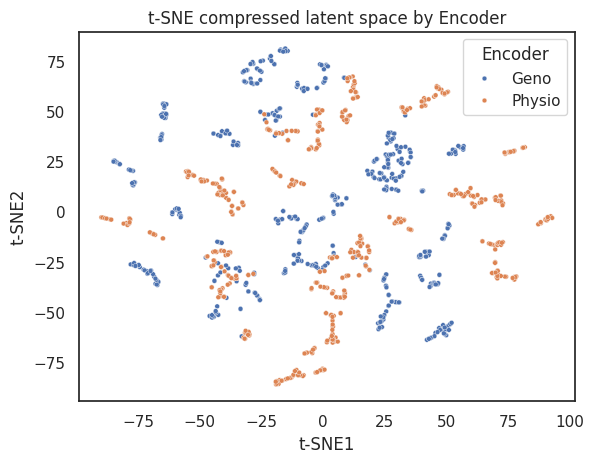

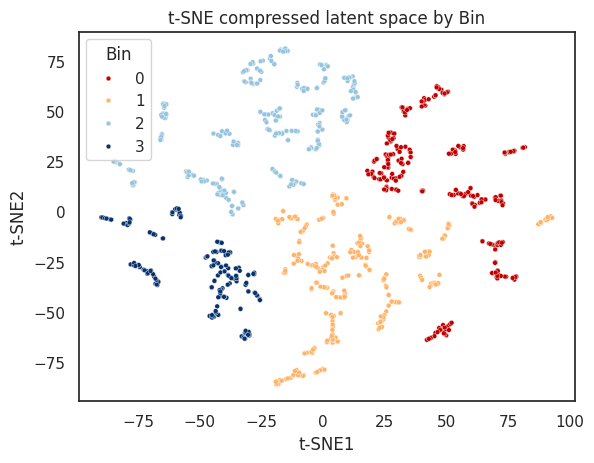

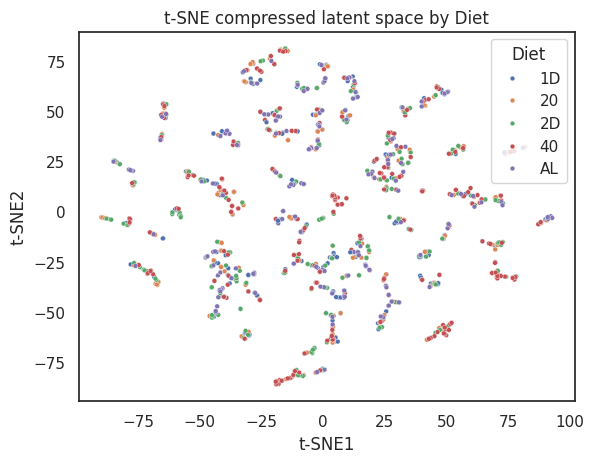

In [20]:
# do the same with tsne dim reduction
tsne = TSNE(n_components=2, perplexity=5, random_state=random_seed)
tsne_embeddings = tsne.fit_transform(latent_space_comb.iloc[:, :latent_dim])
tsne_embedding_df = pd.DataFrame(tsne_embeddings, columns=['t-SNE1', 't-SNE2'])
for hue in hues: 
    tsne_embedding_df[hue] = latent_space_comb[hue]
    plt.figure()
    if hue == 'Bin':
        sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12, palette=custom_palette)
    else:
        sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12)
    plt.title(f't-SNE compressed latent space by {hue}')

Calculate correlations between latent variables

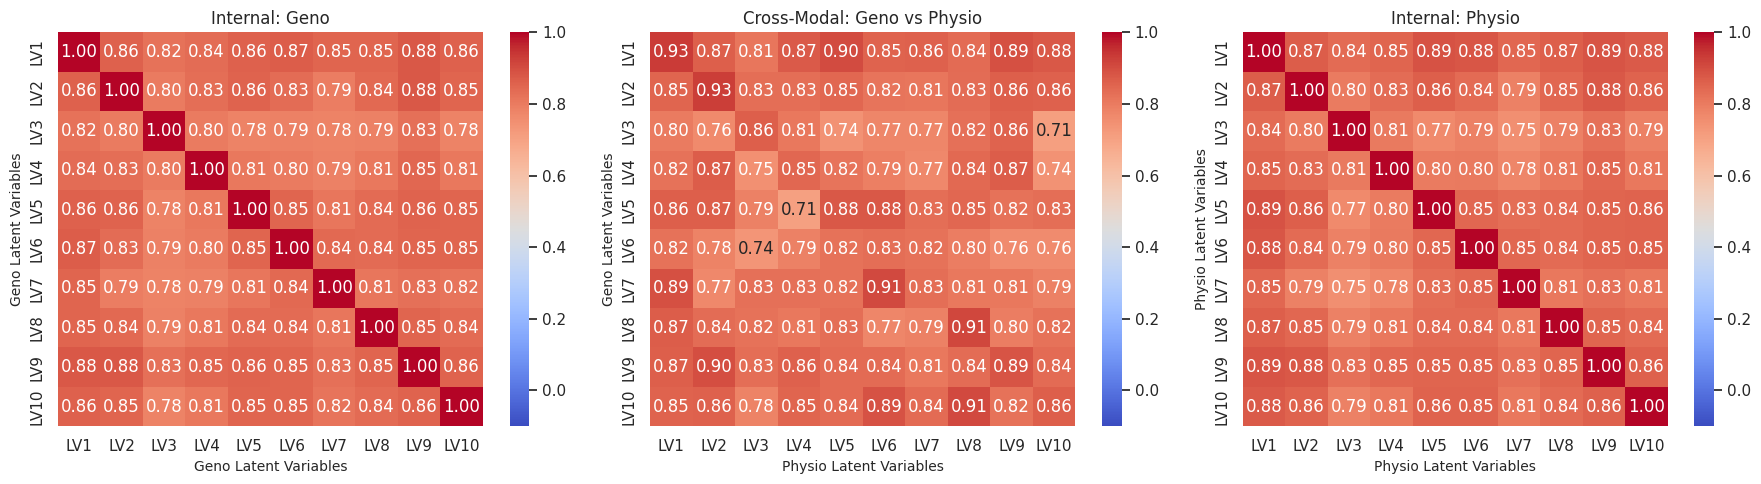

In [21]:
from itertools import combinations_with_replacement
unique_encoders = latent_space_comb['Encoder'].unique()
encoder_pairs = list(combinations_with_replacement(unique_encoders, 2))
latent_cols = latent_space_comb.iloc[:, :latent_dim].columns 

# Filter pairs first to ensure we only plot valid combinations
valid_pairs = []
for enc1, enc2 in encoder_pairs:
    z1 = latent_space_comb[latent_space_comb['Encoder'] == enc1].iloc[:, :latent_dim]
    z2 = latent_space_comb[latent_space_comb['Encoder'] == enc2].iloc[:, :latent_dim]
    if len(z1) == len(z2):
        valid_pairs.append((enc1, enc2, z1, z2))
    else:
        
        print(f"Skipping {enc1} vs {enc2} due to row count mismatch.")

num_plots = len(valid_pairs)

if num_plots > 0:
    # Initialize a single figure with subplots side-by-side
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5), sharey=False)
    
    # Ensure axes is iterable even if there's only 1 plot
    if num_plots == 1:
        axes = [axes]

    for i, (enc1, enc2, z1, z2) in enumerate(valid_pairs):
        ax = axes[i]
        
        # Calculate cross-correlation
        stacked = np.hstack((z1, z2))
        full_corr = np.corrcoef(stacked.T)
        cross_corr = full_corr[:latent_dim, latent_dim:]

        # Plot heatmap on the specific subplot axis
        # cbar_ax creates a shared or individual colorbar; keeping it standard here
        sns.heatmap(
            cross_corr, 
            annot=True, 
            cmap='coolwarm', 
            xticklabels=latent_cols,
            yticklabels=latent_cols, 
            vmin=-0.1, 
            vmax=1,
            ax=ax, 
            fmt=".2f"  # Directs seaborn to the correct subplot
        )
        
        ax.set_xlabel(f"{enc2} Latent Variables", fontsize=10)
        ax.set_ylabel(f"{enc1} Latent Variables", fontsize=10)
        
        if enc1 == enc2:
            ax.set_title(f"Internal: {enc1}", fontsize=12)
        else:
            ax.set_title(f"Cross-Modal: {enc1} vs {enc2}", fontsize=12)

    plt.tight_layout()
    
    # Save the combined figure
    save_path = os.path.join(results_folder, "Combined_Latent_Correlations.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
else:
    print("No valid encoder pairs found to plot.")

Plot distance between paired datapoints

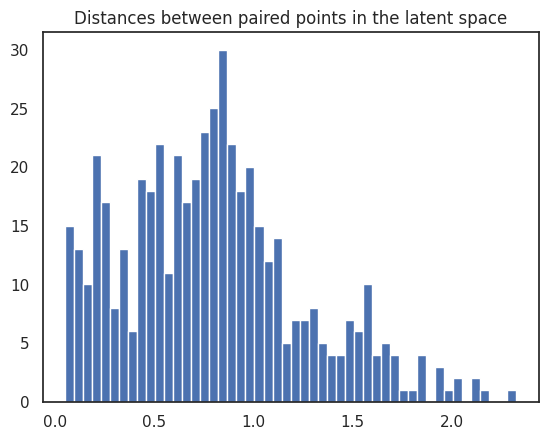

In [22]:
latent_space_comb['pair'] = np.tile(np.arange(1, int(len(latent_space_comb) / 2) + 1), 2)
geno = latent_space_geno.iloc[:, :latent_dim]
physio = latent_space_physio.iloc[:, :latent_dim]
paired_distances = np.linalg.norm(geno.values - physio.values, axis=1)
plt.hist(paired_distances, bins=50)
plt.title('Distances between paired points in the latent space')
plt.savefig(os.path.join(results_folder, 'paired_distances.png'))

Latent traversal across dimensions (traverses in a straight line across individual latent dimensions)

In [23]:
# initialize 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
m1_var_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/genoprobs_var.csv' 
m2_var_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/physio_var.csv' 
m1_var = pd.read_csv(m1_var_path)
m2_var = pd.read_csv(m2_var_path)
vae = torch.load(os.path.join(results_folder, f'saved_model_epoch{epoch}.pth'), map_location=device, weights_only=False)
model_type='CGMVAE'

In [24]:
#initialize relevant functions
# function that takes a latent point, finds the count of the k nearest points, and returns the most popular label 
def find_label(all_latent_data, traversal_point, y, k=20):
    device = traversal_point.device
    all_latent_data = all_latent_data.to(device)
    y = y.to(device)
    dist = torch.linalg.norm(all_latent_data - traversal_point.squeeze(0), dim=1)
    _, top_k_indices = torch.topk(dist, k, largest=False)
    label = torch.mode(y[top_k_indices]).values.item()
    return torch.tensor(label, dtype=torch.long)
def calc_physio_variance(recon, physio_cols, grouped_cols):
    group_vars = []
    recon_df = pd.DataFrame(recon, columns=physio_cols)
    for base_name, cols in grouped_cols.items():
        group_var = np.var(recon_df[cols].values)
        group_vars.append(group_var)
    return group_vars

In [137]:
# compile info required for calculating variance 
physio_input_data = pd.read_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/nature_filtered_nonan_cfc.csv')
physio_col = physio_input_data.columns[3:-2]
grouped_cols = {}
for col in physio_col:
    base = re.sub(r"^Y[a-zA-Z0-9]+_", "", col)
    grouped_cols.setdefault(base, []).append(col)

In [140]:
from scipy.stats import pearsonr

def latent_traversal_summary(
    model,
    latent_data,
    device,
    traversal_dim,
    latent_dims,
    model_type,
    y,
    physio_cols, 
    grouped_cols, 
    num_steps=100,
    k=20,
):
    model.train()

    mean_latent_data = torch.tensor(
        latent_data.iloc[:, :latent_dims].mean(axis=0).values.reshape(1, latent_dims),
        dtype=torch.float32,
    )

    traversal_values = torch.linspace(
        latent_data.iloc[:, traversal_dim - 1].min(),
        latent_data.iloc[:, traversal_dim - 1].max(),
        steps=num_steps,
    )

    with torch.no_grad():
        z_batch = mean_latent_data.repeat(num_steps, 1).to(device)
        z_batch[:, traversal_dim - 1] = traversal_values.to(device)

        if model_type == "VAE":
            recon_m1, _ = model.vaes[0].decode(z_batch)
            recon_m2, _ = model.vaes[1].decode(z_batch)
        else:
            latent_ref = torch.tensor(
                latent_data.iloc[:, :latent_dims].values,
                dtype=torch.float32,
                device=device,
            )
            labels = torch.stack([
                find_label(latent_ref, z.unsqueeze(0), y, k) for z in z_batch
            ]).to(device)

            recon_m1, _ = model.vaes[0].decode(z_batch, labels)
            recon_m2, _ = model.vaes[1].decode(z_batch, labels)

    recon_m1 = recon_m1.detach().cpu().numpy()
    recon_m2 = recon_m2.detach().cpu().numpy()
    traversal_values_np = traversal_values.cpu().numpy()

    cfm1 = recon_m1[:, -2]
    cfm2 = recon_m2[:, -2]

    corr1, _ = pearsonr(traversal_values_np, cfm1)
    corr2, _ = pearsonr(traversal_values_np, cfm2)

    return {
        "traversal_values": traversal_values_np,
        "traversal_range": latent_data.iloc[:, traversal_dim - 1].max() - latent_data.iloc[:, traversal_dim - 1].min(),
        "geno_recon": recon_m1,
        "physio_recon": recon_m2,
        "geno_feature_var": np.var(recon_m1[:, :-2], axis=0),
        "physio_feature_var": calc_physio_variance(recon_m2[:, :-2], physio_col, grouped_cols),
        "geno_feature_mean_abs_change": np.mean(np.abs(recon_m1 - recon_m1[0]), axis=0),
        "physio_feature_mean_abs_change": np.mean(np.abs(recon_m2 - recon_m2[0]), axis=0),
        "geno_total_mean_feature_var": float(np.mean(np.var(recon_m1, axis=0))),
        "physio_total_mean_feature_var": float(np.mean(calc_physio_variance(recon_m2[:, :-2], physio_col, grouped_cols))),
        "geno_total_median_feature_var": float(np.median(np.var(recon_m1, axis=0))),
        "physio_total_median_feature_var": float(np.median(calc_physio_variance(recon_m2[:, :-2], physio_col, grouped_cols))),
        "geno_cfm_corr": float(corr1),
        "physio_cfm_corr": float(corr2),
    }

In [148]:
all_dims = list(range(1, latent_dim + 1))
y = torch.tensor(latent_space_comb["Bin"].values).int()

feature_var_rows = []
cfm_var_rows = []
cfm_rows = []
geno_scores = []
physio_scores = []
geno_cfm_corr = []
physio_cfm_corr = []
geno_recon_rows = []
physio_recon_rows = []

# Collect per-traversal statistics inside the loop; build summary tables afterward.
for dim in all_dims:
    out = latent_traversal_summary(
        model=vae,
        latent_data=latent_space_comb,
        device=device,
        traversal_dim=dim,
        latent_dims=latent_dim,
        model_type=model_type,
        y=y, 
        physio_cols=physio_col, 
        grouped_cols=grouped_cols,
        num_steps=20,
        k=20
    )

    geno_recon = out["geno_recon"]
    physio_recon = out["physio_recon"]

    geno_step_df = pd.DataFrame(geno_recon)
    geno_step_df.insert(0, "step", np.arange(len(geno_step_df)))
    geno_step_df.insert(0, "latent_dim", dim)
    geno_recon_df = geno_step_df.melt(
        id_vars=["latent_dim", "step"],
        var_name="feature_idx",
        value_name="reconstruction",
    )
    geno_recon_rows.append(geno_recon_df)

    physio_step_df = pd.DataFrame(physio_recon)
    physio_step_df.insert(0, "step", np.arange(len(physio_step_df)))
    physio_step_df.insert(0, "latent_dim", dim)
    physio_recon_df = physio_step_df.melt(
        id_vars=["latent_dim", "step"],
        var_name="feature_idx",
        value_name="reconstruction",
    )
    physio_recon_rows.append(physio_recon_df)

    geno_feature_var = out["geno_feature_var"]
    physio_feature_var = out["physio_feature_var"]
    
    for feature_idx, var_val in enumerate(geno_feature_var, start=1):
        feature_var_rows.append({
            "latent_dim": dim,
            "modality": "Geno",
            "feature_idx": feature_idx,
            "variance": var_val,
        })

    for feature_idx, var_val in enumerate(physio_feature_var, start=1):
        feature_var_rows.append({
            "latent_dim": dim,
            "modality": "Physio",
            "feature_idx": feature_idx,
            "variance": var_val,
        })

    cfm_var_rows.append({
        "latent_dim": dim,
        "modality": "Geno",
        "cfm_variance": float(np.var(geno_recon[:, -2])),
    })
    cfm_var_rows.append({
        "latent_dim": dim,
        "modality": "Physio",
        "cfm_variance": float(np.var(physio_recon[:, -2])),
    })

    geno_scores.append(out["geno_total_mean_feature_var"])
    physio_scores.append(out["physio_total_mean_feature_var"])
    geno_cfm_corr.append(out["geno_cfm_corr"])
    physio_cfm_corr.append(out["physio_cfm_corr"])

    for val in geno_recon[:, -2]:
        cfm_rows.append({
            "latent_dim": dim,
            "modality": "Geno",
            "cfm_value": val,
        })

    for val in physio_recon[:, -2]:
        cfm_rows.append({
            "latent_dim": dim,
            "modality": "Physio",
            "cfm_value": val,
        })

geno_recon_df = pd.concat(geno_recon_rows, ignore_index=True)
physio_recon_df = pd.concat(physio_recon_rows, ignore_index=True)

cfm_df = pd.DataFrame(cfm_rows)

feature_var_df = pd.DataFrame(feature_var_rows)
cfm_var_df = pd.DataFrame(cfm_var_rows)

feature_summary_df = (
    feature_var_df
    .groupby(["latent_dim", "modality"], as_index=False)
    .agg(
        mean_variance=("variance", "mean"),
        median_variance=("variance", "median"),
        std_variance=("variance", "std"),
        n_features=("variance", "size"),
    )
)


cfm_summary_df = cfm_var_df.copy()

feature_summary_df
geno_recon_df
physio_recon_df

,latent_dim,step,feature_idx,reconstruction
0,1,0,0,-0.234761
1,1,1,0,-0.234755
2,1,2,0,-0.234755
3,1,3,0,-0.234764
4,1,4,0,-0.234780
...,...,...,...,...
6995,10,15,34,-0.550303
6996,10,16,34,-0.960171
6997,10,17,34,-1.331872
6998,10,18,34,-1.534099


Examine/visualize and verify traversal results

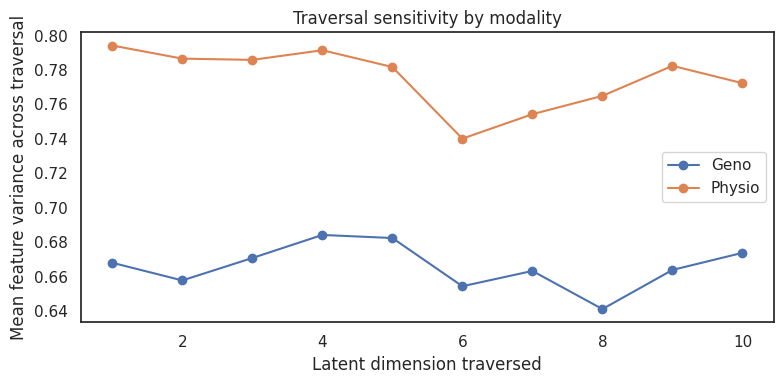

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(all_dims, geno_scores, marker="o", label="Geno")
plt.plot(all_dims, physio_scores, marker="o", label="Physio")
plt.xlabel("Latent dimension traversed")
plt.ylabel("Mean feature variance across traversal")
plt.title("Traversal sensitivity by modality")
plt.legend()
plt.tight_layout()
plt.show()

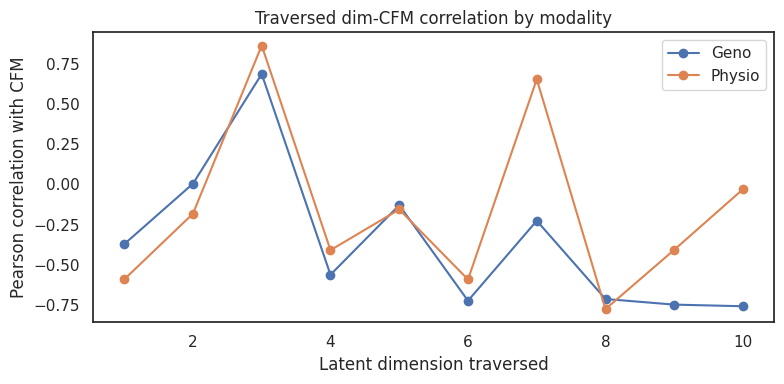

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(all_dims, geno_cfm_corr, marker="o", label="Geno")
plt.plot(all_dims, physio_cfm_corr, marker="o", label="Physio")
plt.xlabel("Latent dimension traversed")
plt.ylabel("Pearson correlation with CFM")
plt.title("Traversed dim-CFM correlation by modality")
plt.legend()
plt.tight_layout()
plt.show()

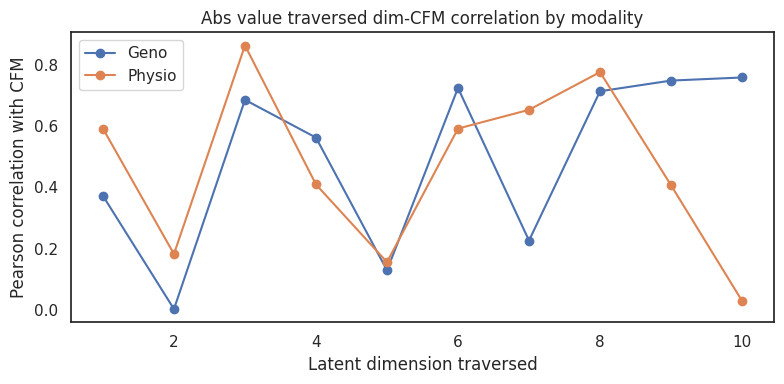

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(all_dims, np.abs(geno_cfm_corr), marker="o", label="Geno")
plt.plot(all_dims, np.abs(physio_cfm_corr), marker="o", label="Physio")
plt.xlabel("Latent dimension traversed")
plt.ylabel("Pearson correlation with CFM")
plt.title("Abs value traversed dim-CFM correlation by modality")
plt.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Correlation w/ CFM')

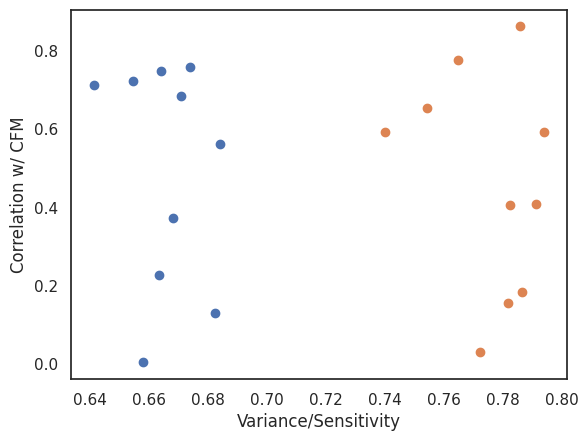

In [37]:
# look at the relationship between sensitivity/variance and correlation 
plt.scatter(geno_scores, np.abs(geno_cfm_corr), label='Geno')
plt.scatter(physio_scores, np.abs(physio_cfm_corr), label='Physio')
plt.xlabel('Variance/Sensitivity')
plt.ylabel('Correlation w/ CFM')

Plot normal latent correlations with CFM to see if they follow similar patterns

In [38]:
original_geno_corr = []
original_physio_corr = []
physio_corr = []
for dim in range(latent_dim):
    geno_corr, _ = pearsonr(latent_space_geno.iloc[:, dim], latent_space_geno['CFM'])
    physio_corr, _ = pearsonr(latent_space_physio.iloc[:, dim], latent_space_physio['CFM'])
    original_geno_corr.append(geno_corr)
    original_physio_corr.append(physio_corr)
pp_geno_corr, _ = pearsonr(df_geno_pp['PP'], latent_space_geno['CFM'])
pp_physio_corr, _ = pearsonr(df_physio_pp['PP'], latent_space_physio['CFM'])
original_geno_corr.append(pp_geno_corr)
original_physio_corr.append(pp_physio_corr)

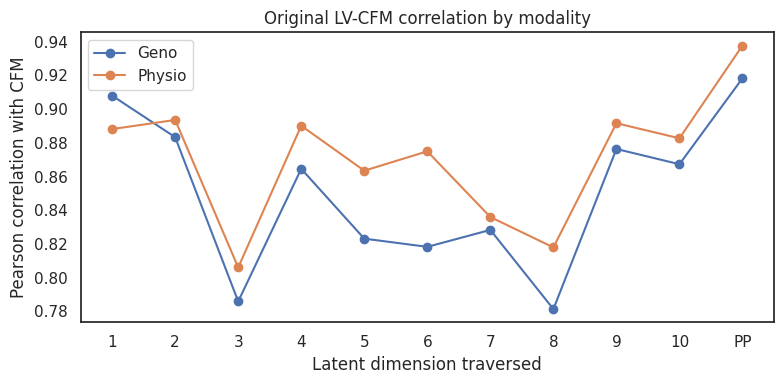

In [39]:
str_all_dims = [str(x) for x in list(range(1, latent_dim + 1))]
str_all_dims.append('PP')
plt.figure(figsize=(8, 4))
plt.plot(str_all_dims, np.abs(original_geno_corr), marker="o", label="Geno")
plt.plot(str_all_dims, np.abs(original_physio_corr), marker="o", label="Physio")
plt.xlabel("Latent dimension traversed")
plt.ylabel("Pearson correlation with CFM")
plt.title("Original LV-CFM correlation by modality")
plt.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Original LV Correlation w/ CFM')

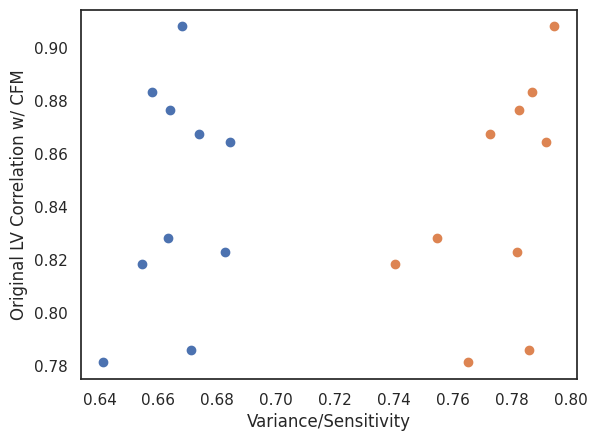

In [40]:
plt.scatter(geno_scores, np.abs(original_geno_corr[:-1]), label='Geno')
plt.scatter(physio_scores, np.abs(original_geno_corr[:-1]), label='Physio')
plt.xlabel('Variance/Sensitivity')
plt.ylabel('Original LV Correlation w/ CFM')

In [149]:
all_dims = list(range(1, latent_dim + 1))
y = torch.tensor(latent_space_comb["Bin"].values).int()

feature_var_rows = []
cfm_var_rows = []
cfm_rows = []

for dim in all_dims:
    out = latent_traversal_summary(
        model=vae,
        latent_data=latent_space_comb,
        device=device,
        traversal_dim=dim,
        latent_dims=latent_dim,
        model_type=model_type,
        y=y,
        physio_cols=physio_col, 
        grouped_cols=grouped_cols,
        num_steps=10,
        k=20,
    )

    # geno_recon = out["geno_recon"]
    # physio_recon = out["physio_recon"]

    geno_feature_var = out["geno_feature_var"]
    physio_feature_var = out["physio_feature_var"]

    for feature_idx, var_val in enumerate(geno_feature_var, start=1):
        feature_var_rows.append({
            "latent_dim": dim,
            "modality": "Geno",
            "feature_idx": feature_idx,
            "variance": var_val,
        })

    for feature_idx, var_val in enumerate(physio_feature_var, start=1):
        feature_var_rows.append({
            "latent_dim": dim,
            "modality": "Physio",
            "feature_idx": feature_idx,
            "variance": var_val,
        })

    cfm_var_rows.append({
        "latent_dim": dim,
        "modality": "Geno",
        "cfm_variance": float(np.var(geno_recon[:, -2])),
    })
    cfm_var_rows.append({
        "latent_dim": dim,
        "modality": "Physio",
        "cfm_variance": float(np.var(physio_recon[:, -2])),
    })


    for val in geno_recon[:, -1]:
        cfm_rows.append({
            "latent_dim": dim,
            "modality": "Geno",
            "cfm_value": val,
        })

    for val in physio_recon[:, -1]:
        cfm_rows.append({
            "latent_dim": dim,
            "modality": "Physio",
            "cfm_value": val,
        })

cfm_df = pd.DataFrame(cfm_rows)
cfm_df

feature_var_df = pd.DataFrame(feature_var_rows)
cfm_var_df = pd.DataFrame(cfm_var_rows)

feature_summary_df = (
    feature_var_df
    .groupby(["latent_dim", "modality"], as_index=False)
    .agg(
        mean_variance=("variance", "mean"),
        median_variance=("variance", "median"),
        std_variance=("variance", "std"),
        n_features=("variance", "size"),
    )
)

cfm_summary_df = cfm_var_df.copy()

feature_summary_df

,latent_dim,modality,mean_variance,median_variance,std_variance,n_features
0,1,Geno,0.663944,0.517185,0.507902,5873
1,1,Physio,0.793755,0.776280,0.246872,11
2,2,Geno,0.647473,0.512743,0.484260,5873
3,2,Physio,0.782921,0.775570,0.241065,11
4,3,Geno,0.653387,0.514897,0.491265,5873
5,3,Physio,0.787689,0.776330,0.241423,11
6,4,Geno,0.671702,0.525448,0.509959,5873
7,4,Physio,0.790040,0.776319,0.248487,11
8,5,Geno,0.673429,0.525669,0.514582,5873
9,5,Physio,0.778197,0.776117,0.238259,11


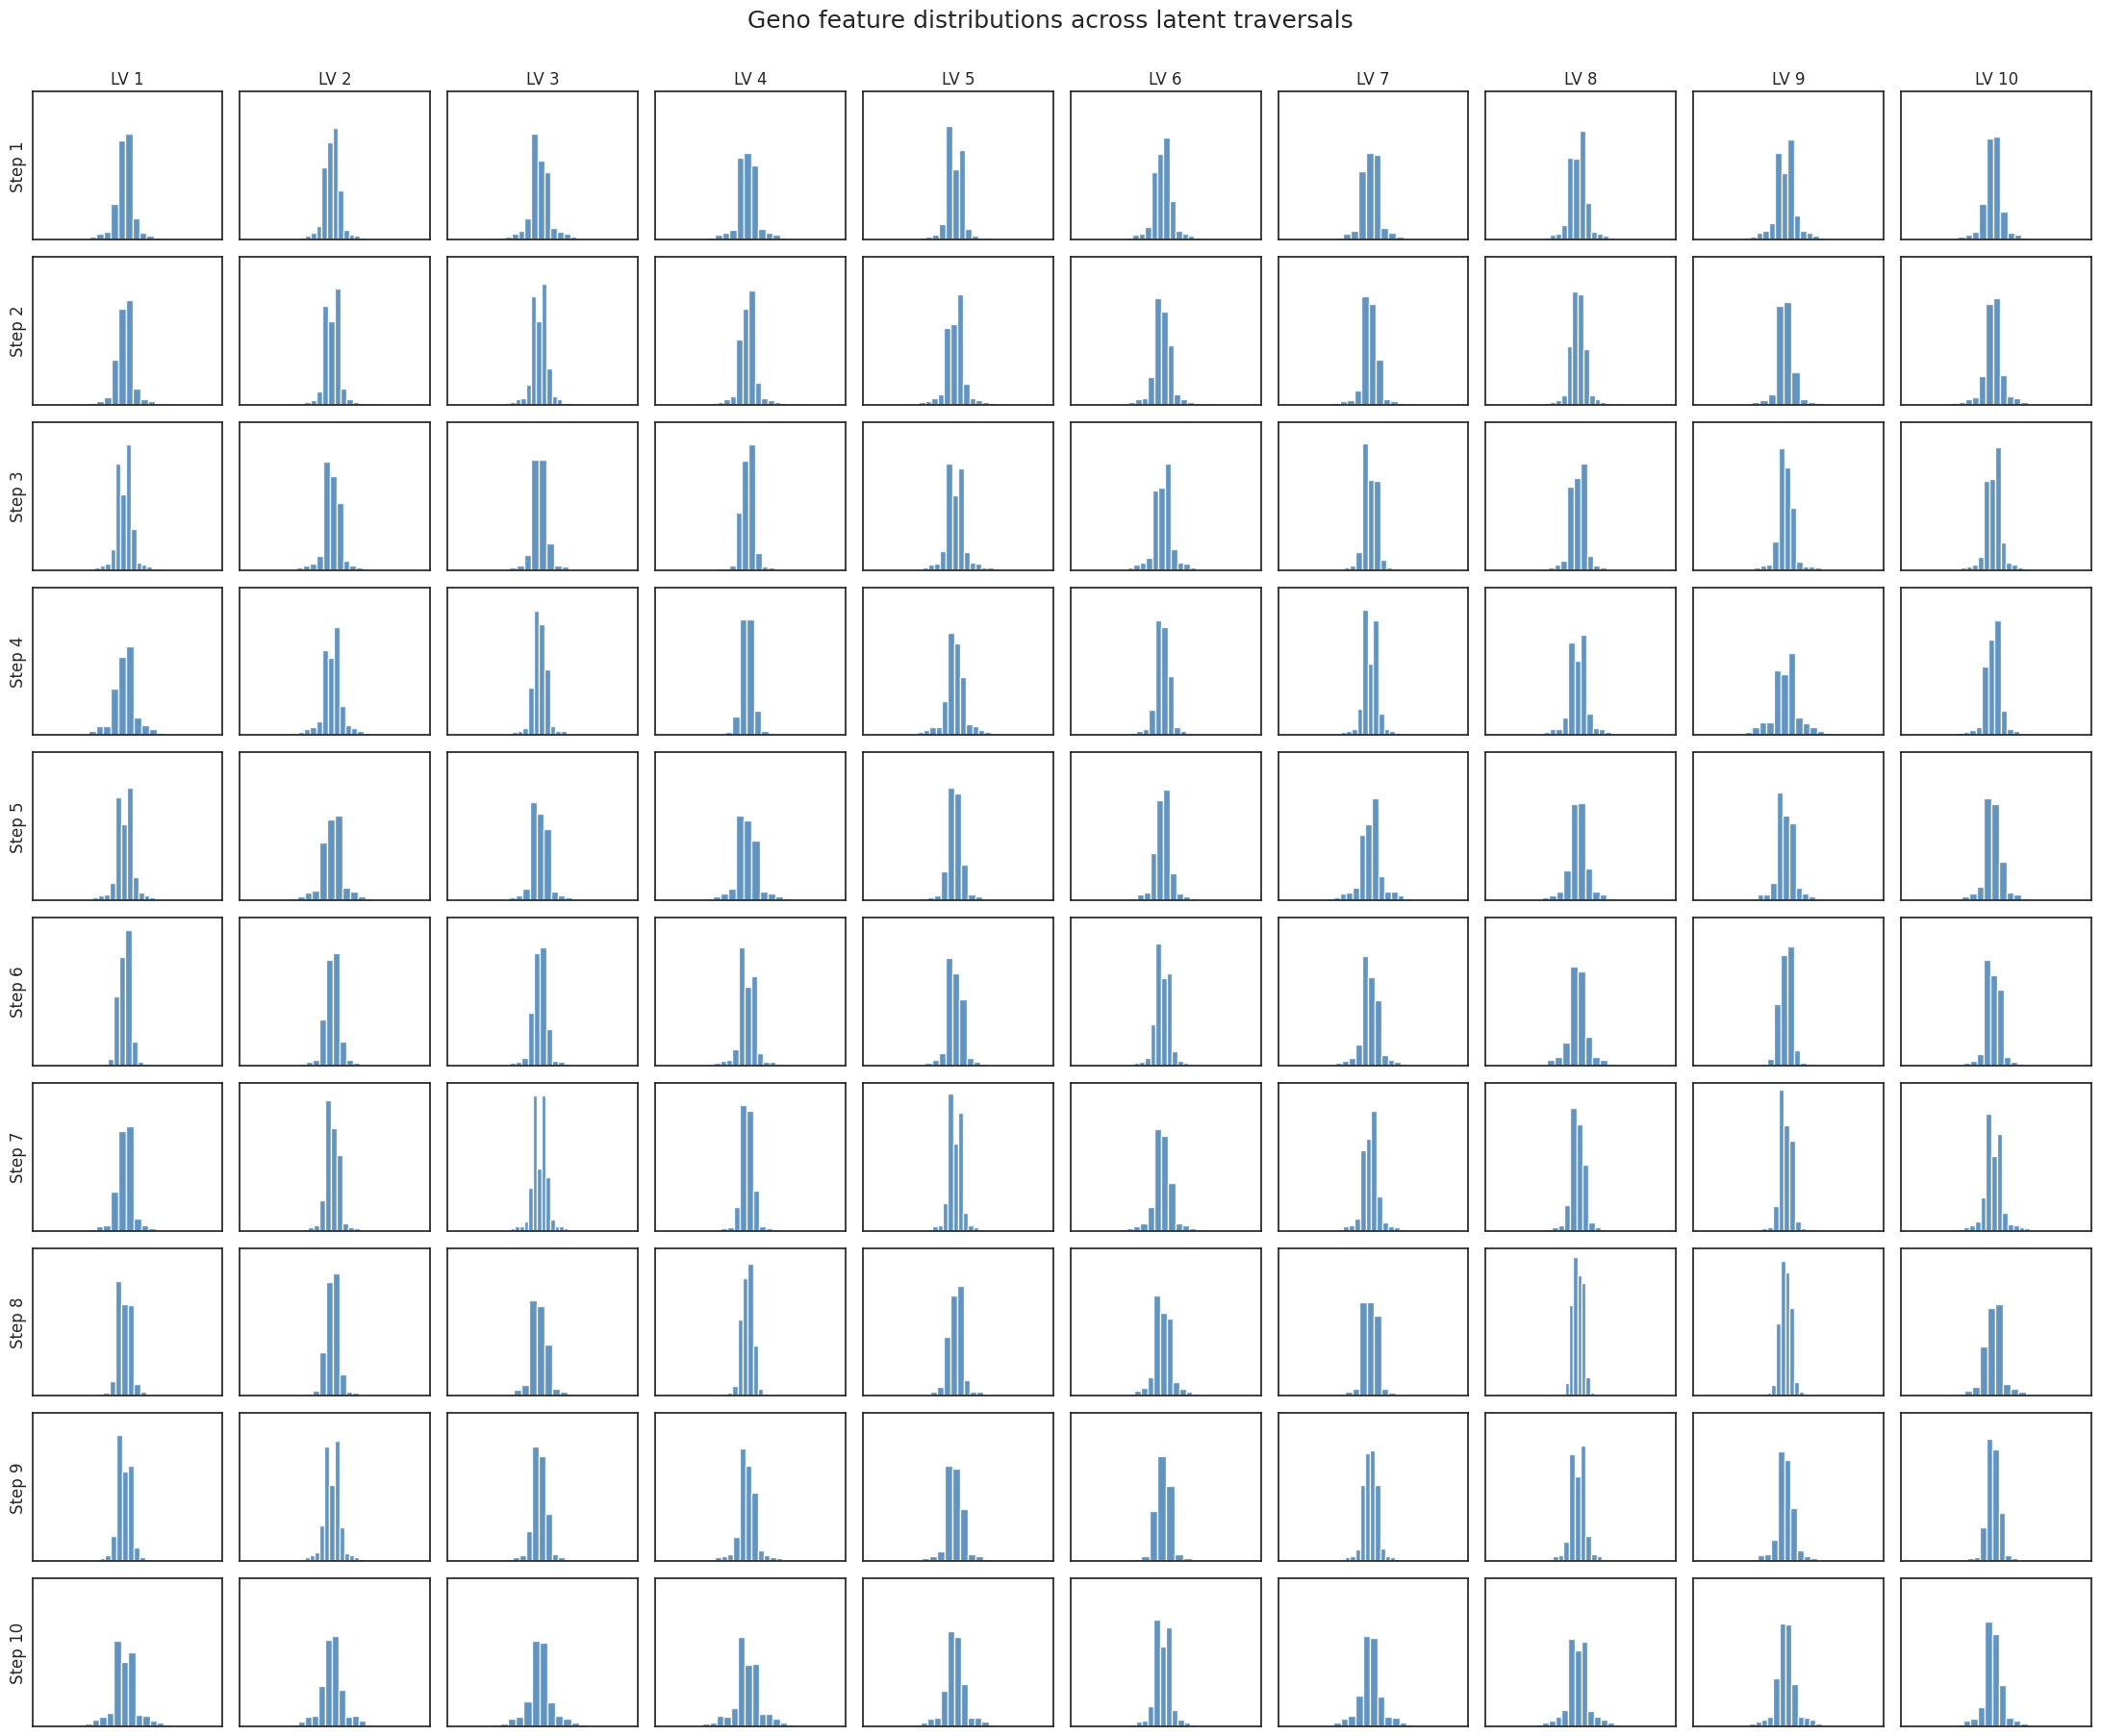

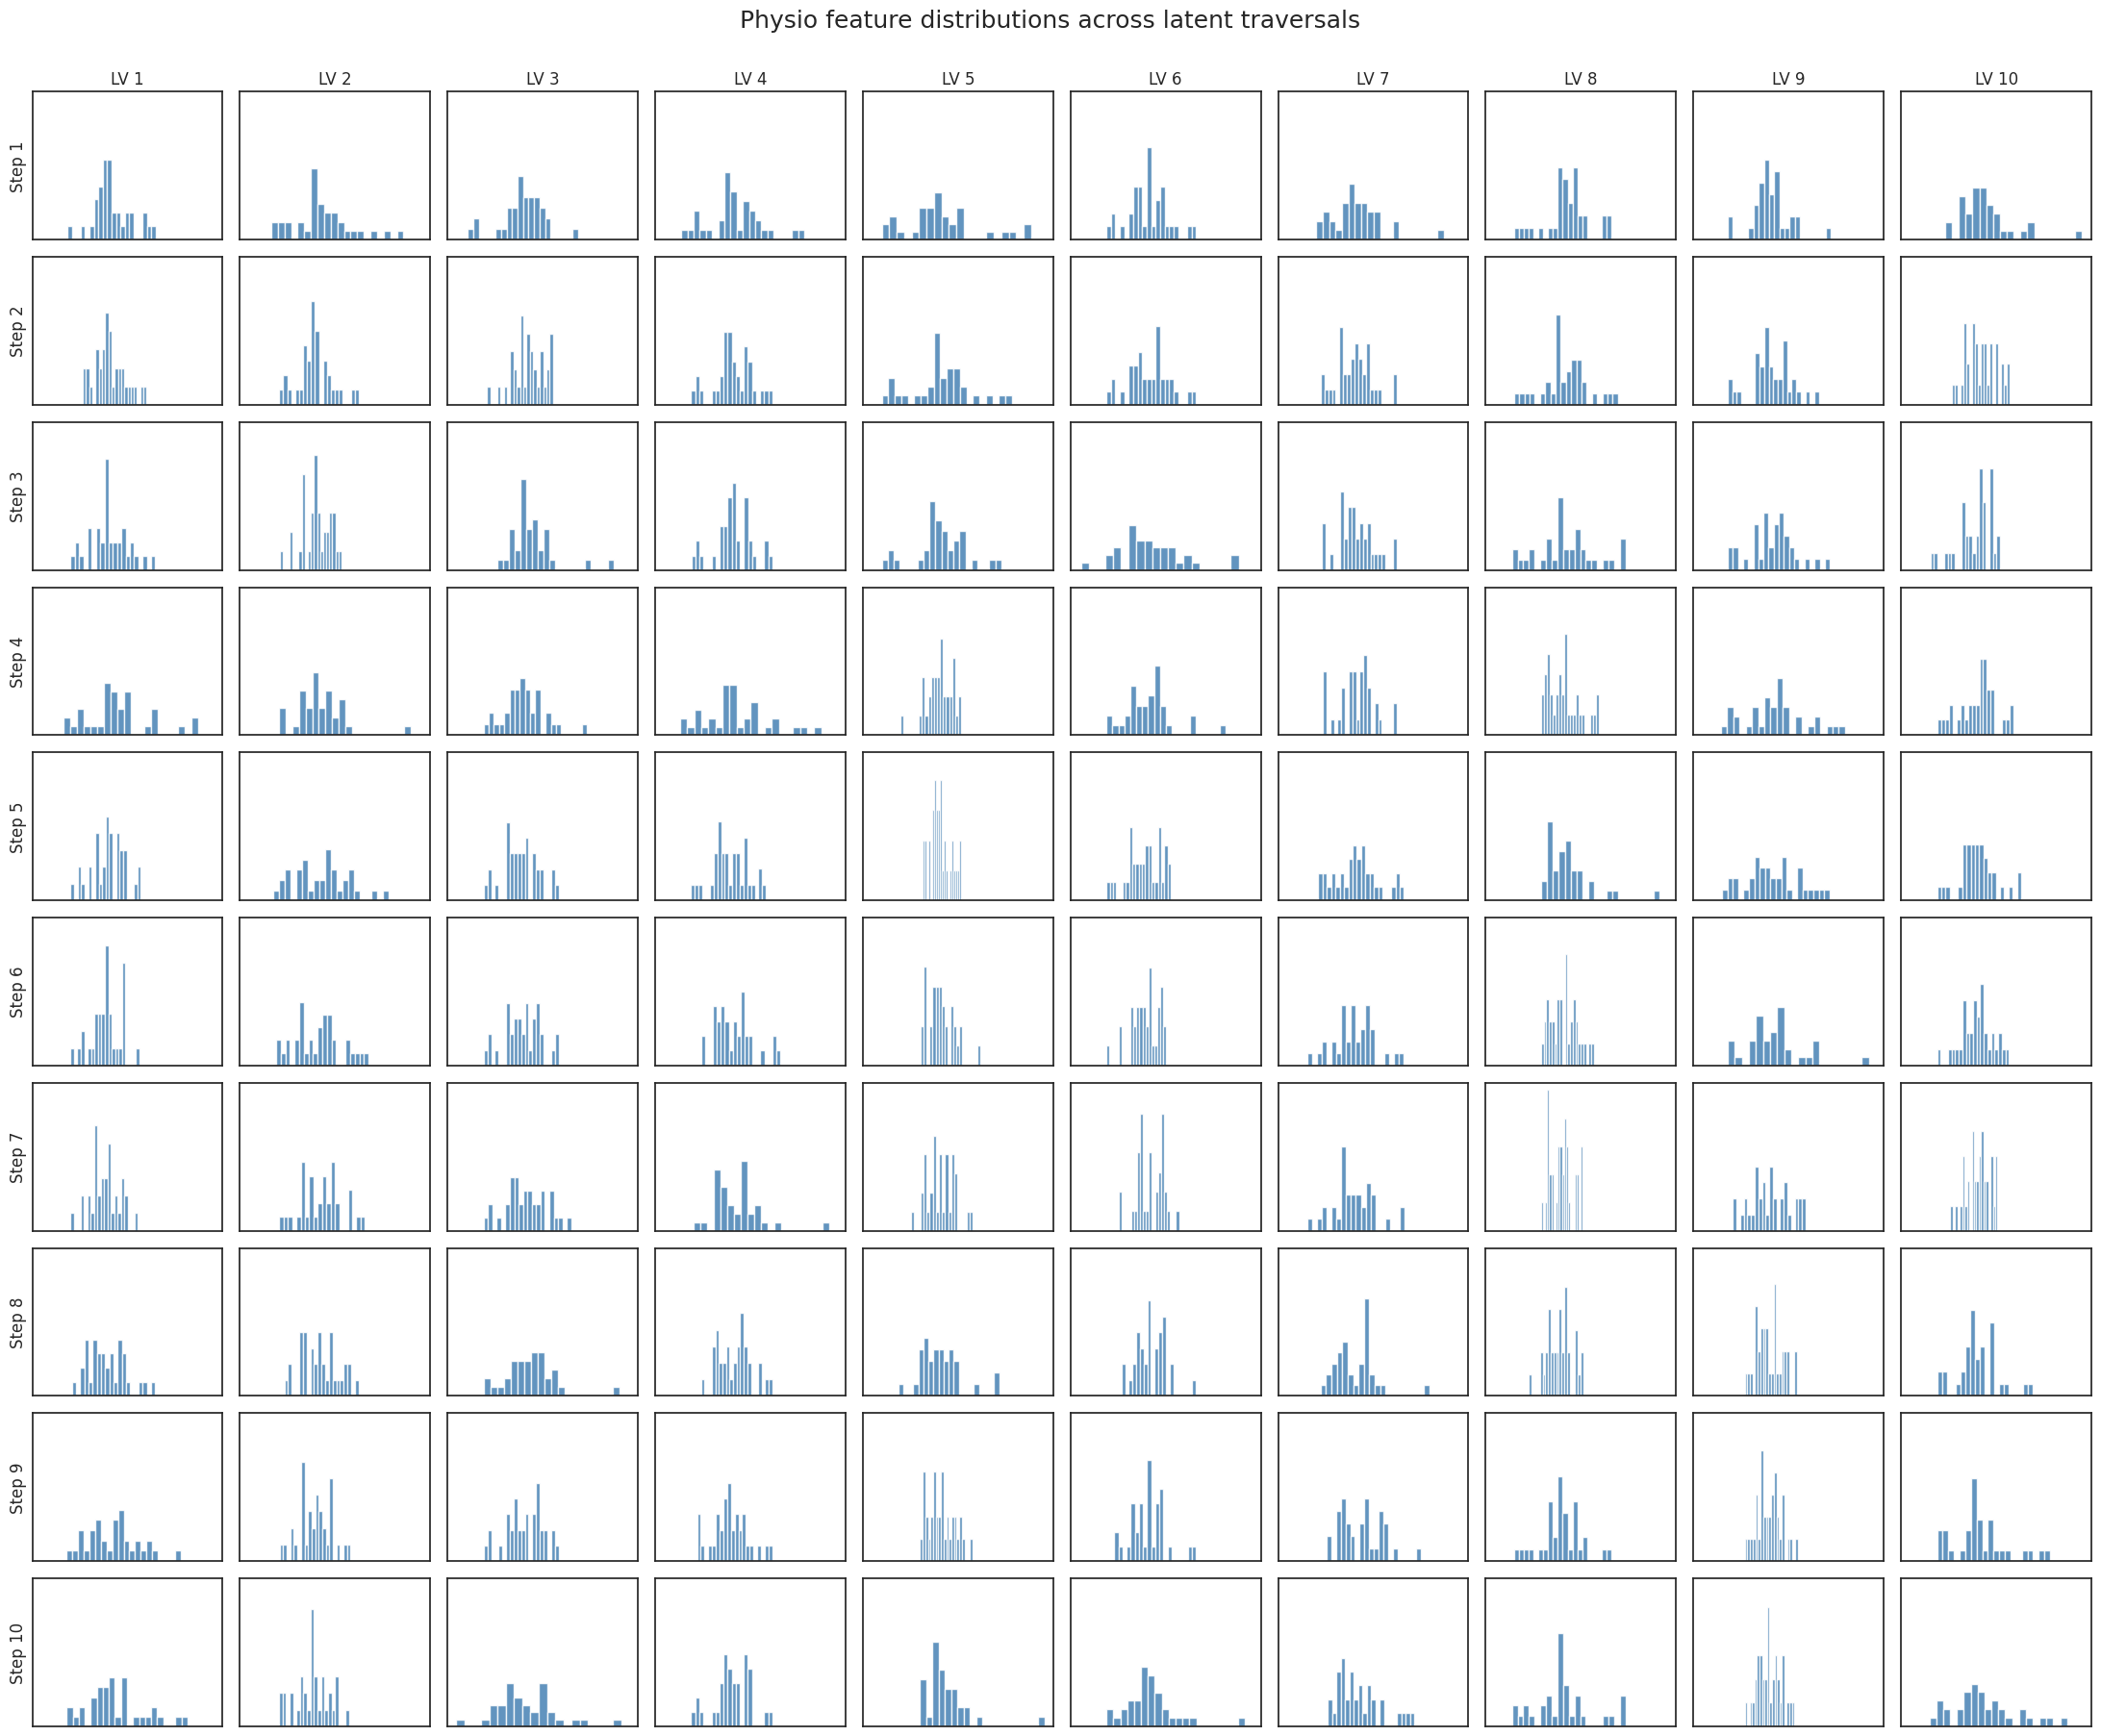

In [150]:
num_steps = 10

def plot_traversal_histogram_grid(modality_key, title, bins=20):
    fig, axes = plt.subplots(
        num_steps,
        latent_dim,
        figsize=(2.2 * latent_dim, 1.8 * num_steps),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)

    for dim in range(1, latent_dim + 1):
        out = latent_traversal_summary(
            model=vae,
            latent_data=latent_space_comb,
            device=device,
            traversal_dim=dim,
            latent_dims=latent_dim,
            model_type=model_type,
            y=y,
            physio_cols=physio_cols, 
            grouped_cols=grouped_cols,
            num_steps=num_steps,
            k=20,
        )

        recon = np.asarray(out[modality_key])
        if recon.ndim > 2:
            recon = recon.reshape(recon.shape[0], -1)

        for step_idx in range(num_steps):
            ax = axes[step_idx, dim - 1]
            feature_values = np.asarray(recon[step_idx]).ravel()
            ax.hist(feature_values, bins=bins, color="steelblue", alpha=0.85, density=True)
            ax.set_xticks([])
            ax.set_yticks([])

            if step_idx == 0:
                ax.set_title(f"LV {dim}")
            if dim == 1:
                ax.set_ylabel(f"Step {step_idx + 1}")

    fig.suptitle(title, fontsize=18, y=1.002)
    fig.tight_layout()
    plt.show()

plot_traversal_histogram_grid("geno_recon", "Geno feature distributions across latent traversals")
plot_traversal_histogram_grid("physio_recon", "Physio feature distributions across latent traversals")

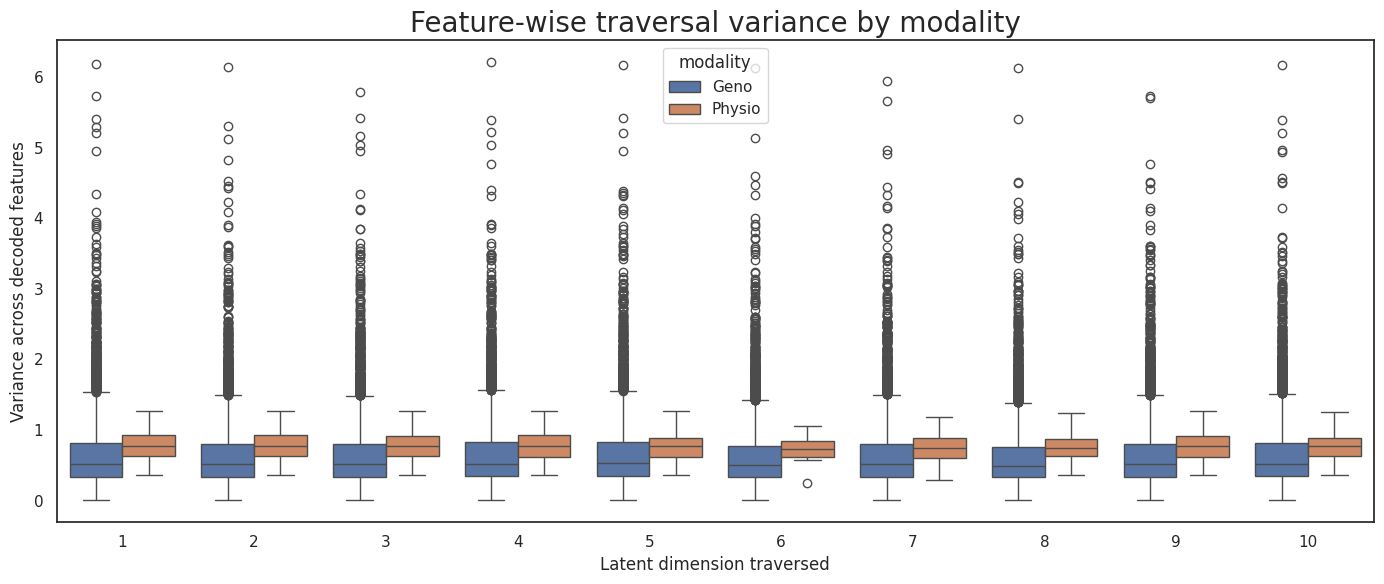

In [151]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=feature_var_df,
    x="latent_dim",
    y="variance",
    hue="modality",
)
plt.xlabel("Latent dimension traversed")
plt.ylabel("Variance across decoded features")
plt.title("Feature-wise traversal variance by modality", fontsize=20)
plt.tight_layout()
plt.show()

In [152]:
from scipy.stats import levene

# Levene's test: compare CFM distributions between modalities for each latent dimension.
levene_results = []
for dim in sorted(cfm_df["latent_dim"].unique()):
    sub = cfm_df[cfm_df["latent_dim"] == dim]
    geno_vals = sub[sub["modality"] == "Geno"]["cfm_value"].to_numpy()
    physio_vals = sub[sub["modality"] == "Physio"]["cfm_value"].to_numpy()

    if len(geno_vals) == 0 or len(physio_vals) == 0:
        continue

    stat, pval = levene(geno_vals, physio_vals, center="median")
    levene_results.append({
        "latent_dim": dim,
        "levene_stat": stat,
        "p_value": pval,
        "significant": bool(pval < 0.05),
    })

levene_df = pd.DataFrame(levene_results).sort_values("latent_dim").reset_index(drop=True)
levene_df["star"] = np.where(levene_df["significant"], "*", "")
levene_df

,latent_dim,levene_stat,p_value,significant,star
0,1,0.268544,0.607315,False,
1,2,0.268544,0.607315,False,
2,3,0.268544,0.607315,False,
3,4,0.268544,0.607315,False,
4,5,0.268544,0.607315,False,
5,6,0.268544,0.607315,False,
6,7,0.268544,0.607315,False,
7,8,0.268544,0.607315,False,
8,9,0.268544,0.607315,False,
9,10,0.268544,0.607315,False,


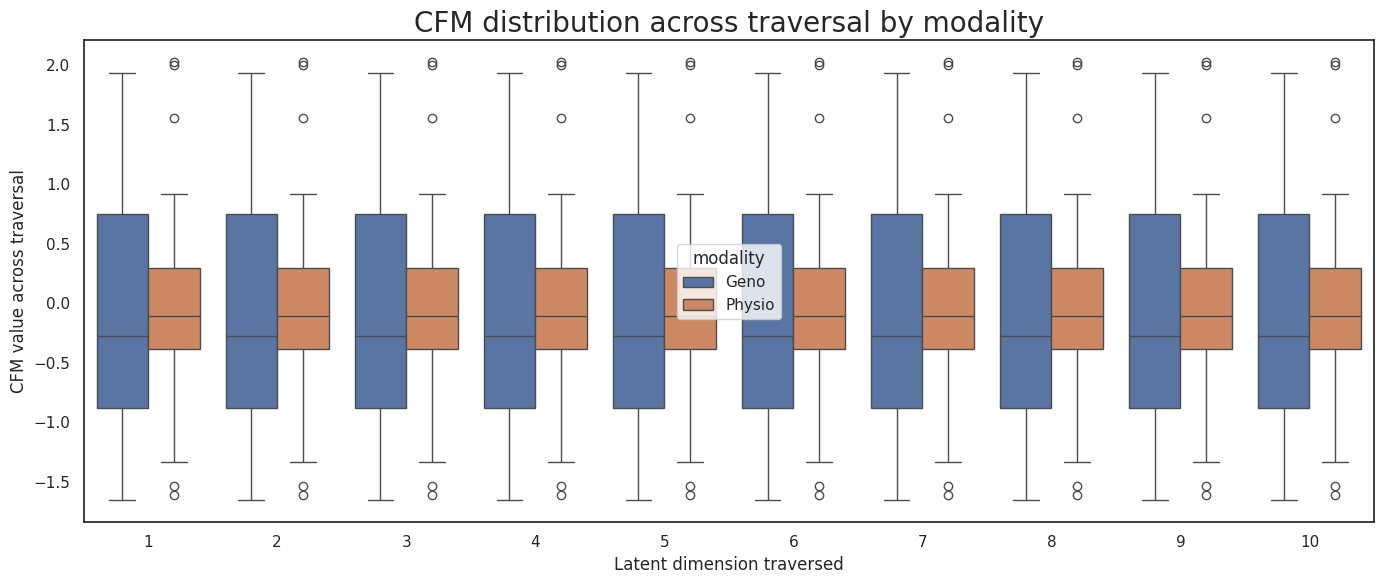

In [153]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=cfm_df,
    x="latent_dim",
    y="cfm_value",
    hue="modality",
)
plt.xlabel("Latent dimension traversed")
plt.ylabel("CFM value across traversal")
plt.title("CFM distribution across traversal by modality", fontsize=20)
plt.tight_layout()
plt.show()

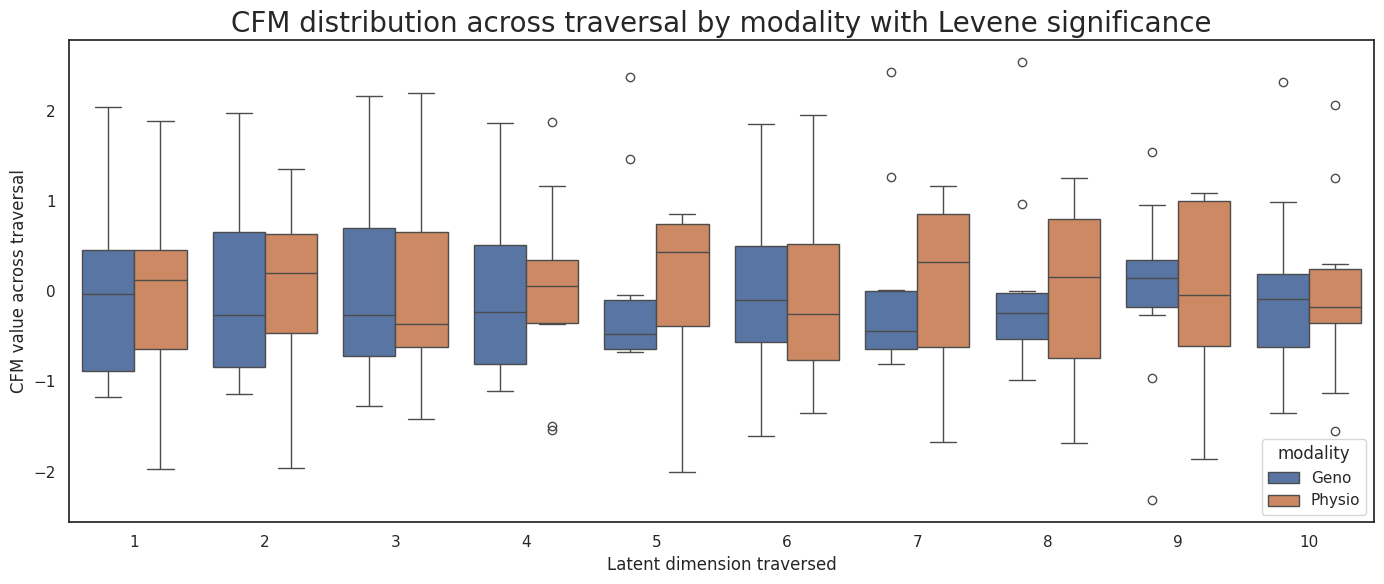

,latent_dim,levene_stat,p_value,significant,star
0,1,0.037784,0.848054,False,
1,2,0.026816,0.871747,False,
2,3,0.007802,0.930589,False,
3,4,0.025373,0.875215,False,
4,5,0.112797,0.740865,False,
5,6,0.000054,0.994228,False,
6,7,0.273195,0.607570,False,
7,8,0.313002,0.582739,False,
8,9,0.758267,0.395337,False,
9,10,0.002342,0.961938,False,


In [46]:
# Plot the CFM distributions with significance markers added for any LV whose
# Geno vs Physio CFM distributions differ significantly by Levene's test.
summary = cfm_df.groupby(["latent_dim", "modality"])["cfm_value"].agg(["mean", "median", "std"]).reset_index()

# Merge with the significance labels so each latent dimension can be annotated.
annot_df = summary.merge(levene_df[["latent_dim", "significant", "star"]], on="latent_dim", how="left")
annot_df = annot_df.sort_values("latent_dim").reset_index(drop=True)

# Use a single annotation on top of each LV's distribution for a compact presentation.
plot_df = cfm_df.copy()
plot_df["latent_dim"] = plot_df["latent_dim"].astype(int)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=plot_df, x="latent_dim", y="cfm_value", hue="modality", ax=ax)

for idx, row in levene_df.iterrows():
    if row["significant"]:
        x_pos = idx + 0.5
        y_top = plot_df[plot_df["latent_dim"] == row["latent_dim"]]["cfm_value"].max()
        ax.text(
            x_pos,
            y_top + 0.05 * (plot_df["cfm_value"].max() - plot_df["cfm_value"].min() + 1e-8),
            row["star"],
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            color="black",
        )

ax.set_xlabel("Latent dimension traversed")
ax.set_ylabel("CFM value across traversal")
ax.set_title("CFM distribution across traversal by modality with Levene significance", fontsize=20)
plt.tight_layout()
plt.show()

levene_df

In [47]:
cfm_var_df = cfm_df.groupby(["latent_dim", "modality"])["cfm_value"].std().reset_index()
cfm_var_df

,latent_dim,modality,cfm_value
0,1,Geno,1.052687
1,1,Physio,1.051207
2,2,Geno,1.052750
3,2,Physio,1.051203
4,3,Geno,1.052798
5,3,Physio,1.051328
6,4,Geno,1.052878
7,4,Physio,1.051555
8,5,Geno,1.052879
9,5,Physio,1.051580


In [48]:
cfm_summary_table = (
    cfm_summary_df
    .pivot(index="latent_dim", columns="modality", values="cfm_variance")
    .reset_index()
)

cfm_summary_table

modality,latent_dim,Geno,Physio
0,1,0.997335,0.994532
1,2,0.997455,0.994526
2,3,0.997546,0.994761
3,4,0.997698,0.995191
4,5,0.997699,0.995238
5,6,0.997204,0.994767
6,7,0.997669,0.993017
7,8,0.997670,0.995224
8,9,0.996740,0.994908
9,10,0.997317,0.995366


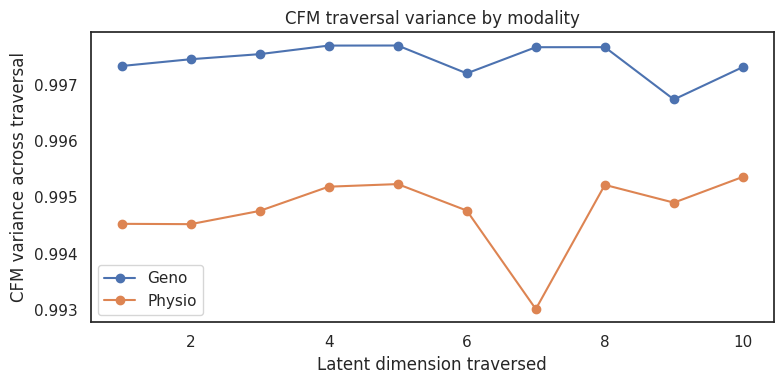

In [49]:
plt.figure(figsize=(8, 4))
plt.plot(
    cfm_summary_table["latent_dim"],
    cfm_summary_table["Geno"],
    marker="o",
    label="Geno",
)
plt.plot(
    cfm_summary_table["latent_dim"],
    cfm_summary_table["Physio"],
    marker="o",
    label="Physio",
)
plt.xlabel("Latent dimension traversed")
plt.ylabel("CFM variance across traversal")
plt.title("CFM traversal variance by modality")
plt.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Correlation w/ CFM')

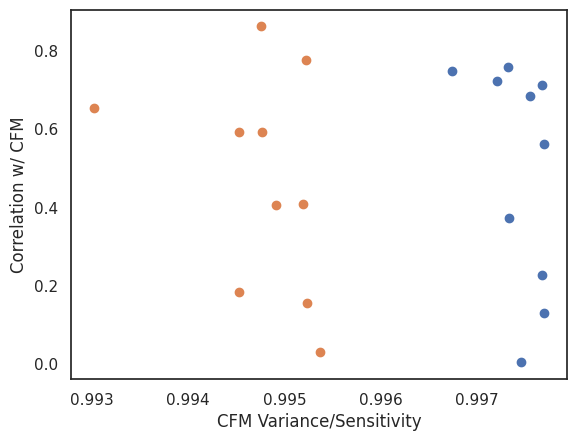

In [50]:
# look at the relationship between sensitivity/variance and correlation 
plt.scatter(cfm_summary_table["Geno"], np.abs(geno_cfm_corr), label='Geno')
plt.scatter(cfm_summary_table["Physio"], np.abs(physio_cfm_corr), label='Physio')
plt.xlabel('CFM Variance/Sensitivity')
plt.ylabel('Correlation w/ CFM')

KL divergence across encoders

In [51]:
# initialize relevant parameters
input_dim = [5873, 33]
num_classes = 4

In [60]:
def _seed_worker(worker_id):
    worker_seed = random_seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(random_seed)

In [61]:
# create dataloader 
paired_df = pd.read_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio_restandardized_cfc.csv')
physio_cols = paired_df.iloc[:, input_dim[0]+3:input_dim[0]+input_dim[1]+3].columns
physio_cols = list(physio_cols)
physio_cols.append('cfm')
physio_cols.append('lifespan')
label_col = 'cfc_bin'
cfm_col = 'CFC.24mo.Average'
life_col = 'SurvDays'
mouse_id_col = 'MouseID'
diet_col = 'Diet'
paired_df[cfm_col] = standardizer(paired_df[cfm_col], 'cfm')
paired_df[life_col] = standardizer(paired_df[life_col], 'lifespan')
paired_df, cfc_bin_edges = assign_cfc_bins(paired_df, cfm_col, num_classes, label_col)
test_dataset = PairedDataset(paired_df, input_dim, label_col, cfm_col, life_col, mouse_id_col, diet_col)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), num_workers=0, worker_init_fn=_seed_worker, generator=g)

In [81]:
gmm_centers = pd.read_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/do_gmm_centers_range2.csv')
gmm_centers = gmm_centers.iloc[:, 1:]

In [82]:
gmm_centers

,center1,center2,center3,center4
0,-2.740040,-2.096744,-1.656571,-1.029869
1,-2.631481,-2.401482,-1.784351,-1.025563
2,-2.539615,-2.188422,-1.668306,-1.437687
3,-2.549977,-2.246439,-1.666554,-1.336909
4,-2.651396,-2.222794,-1.904080,-1.167535
5,-2.810427,-2.125933,-1.912986,-1.215447
6,-2.796962,-2.083137,-1.848062,-1.394909
7,-2.607121,-2.196669,-1.838875,-1.279107
8,-2.662186,-2.244413,-1.603132,-1.020084
9,-2.632019,-2.170575,-1.858107,-1.168073


In [53]:
# modifying functions to calculate KL divergence for individual point distributions rather than the entire batch 
# the only function that should actually change is mean_squared_covariance_gmm
def mean_squared_covariance_gmm_withvar(embedding_matrix, gmm_centers, gmm_std):
    sigma = compute_empirical_covariance(embedding_matrix)
    comp_covariance, gmm_covariance = compute_gmm_covariance(gmm_centers, gmm_std)
    comp_covariance.to(embedding_matrix.device)
    gmm_covariance.to(embedding_matrix.device)
    diff = torch.pow(sigma - gmm_covariance, 2)
    mean_cov = torch.mean(diff)
    return mean_cov

In [54]:
# def calc_kl(vae, latent_dim, x, label, gmm_centers, ks_weight, cv_weight, device="cpu"):
#     vae.encoder.eval()

#     all_kl_per_dim = []
#     x = x.to(device)
#     mu, logsigma, z, y, cfm = vae.decode(x, label)

#     ks_loss = mean_squared_kolmogorov_smirnov_distance_gmm_broadcasting(mu, gmm_centers, logsigma)
#     cv_loss = mean_squared_covariance_gmm(mu, gmm_centers, logsigma)
#     kl_loss = ks_weight * ks_loss + cv_weight * cv_loss

#     print(kl_loss.shape)

In [114]:
# this function takes in a single modality, and calculates the KL across all samples/latent variables
def calc_kl(vae, latent_dim, x, label, cfm, lifespan, gmm_centers, sigma_p, device='cpu'):
    vae.eval()

    #all_kl_per_dim = []

    x = x.to(device)
    label = label.to(device)
    cfm = cfm.to(device)
    lifespan = lifespan.to(device)
    mus, logsigmas, z, y, cfm = vae.encode(x, label, cfm, lifespan)
    mus = mus.detach().cpu().numpy()
    logsigmas = logsigmas.detach().cpu().numpy()

    all_kl = []
    for ind in range(latent_dim):
        LV_centers = gmm_centers[ind]
        LV_mus = mus[:, ind]
        LV_sigmas = logsigmas[:, ind]
        kl_per_latent_dim = []
        for i, (mu, sigma) in enumerate(zip(LV_mus, LV_sigmas)):
            mu_p = LV_centers[label[i]]
            point_kl = np.log(sigma_p/sigma) + (sigma**2 + (mu - mu_p)**2) / (2*sigma_p**2) - 0.5
            kl_per_latent_dim.append(point_kl)
        all_kl.append(kl_per_latent_dim)

    return np.array(all_kl)

In [85]:
first_iter = next(iter(test_loader))

In [117]:
geno_all_kl = calc_kl(vae.vaes[0], 10, first_iter[0][1], first_iter[0][2], first_iter[0][3], first_iter[0][4], gmm_centers.values, 0.05, device='cuda:0')
physio_all_kl = calc_kl(vae.vaes[1], 10, first_iter[1][1], first_iter[0][2], first_iter[0][3], first_iter[0][4], gmm_centers.values, 0.05, device='cuda:0')

In [122]:
geno_df = pd.DataFrame(geno_all_kl.T, columns=[f'LV{i+1}' for i in range(latent_dim)])
geno_long = geno_df.melt(var_name="latent_dim", value_name="kl")
geno_long["modality"] = "Geno"

physio_df = pd.DataFrame(physio_all_kl.T, columns=[f'LV{i+1}' for i in range(latent_dim)])
physio_long = physio_df.melt(var_name="latent_dim", value_name="kl")
physio_long["modality"] = "Physio"

kl_df = pd.concat([geno_long, physio_long], ignore_index=True)

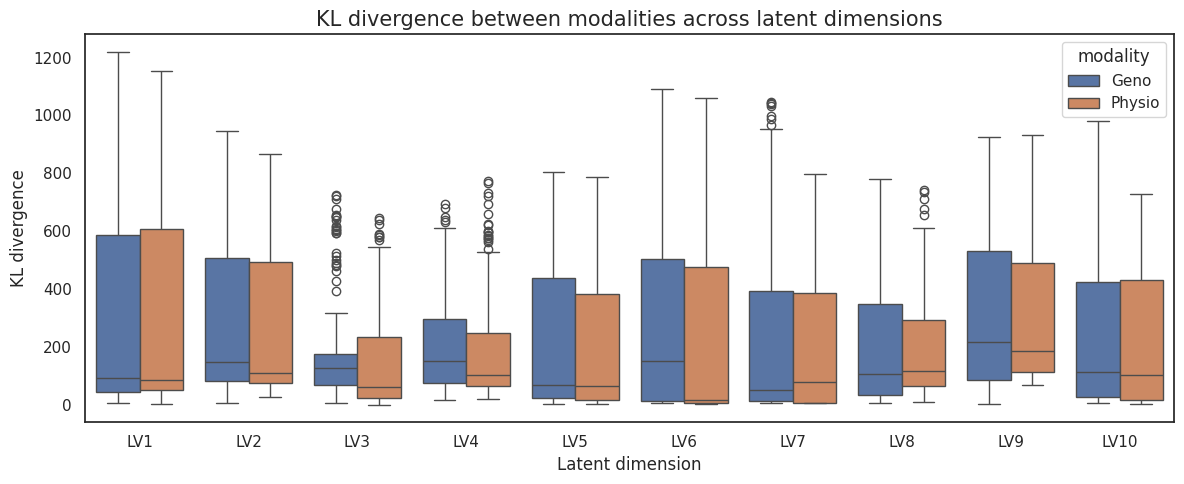

In [127]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=kl_df, x="latent_dim", y="kl", hue="modality")
plt.xlabel("Latent dimension")
plt.ylabel("KL divergence")
plt.title('KL divergence between modalities across latent dimensions', fontsize=15)
plt.tight_layout()
plt.show()

First: Looking at decoder gradients to determine which LV are the most important to reconstruction

In [ ]:
# to do this, we calculate the gradient of the latent vector z with respect to the decoder output 
# (this is a similar concept to the latent traversal analysis that is done previously)
def compute_integrated_gradients(decoder, z, label, baseline_type="mean", steps=50):
    # z is the latent tensor
    # z baseline is the reference latent tensor
    # steps is the number of interpolation steps
    decoder.eval()
    num_samples, latent_dim = z.shape
    # z = torch.Tensor(z)

    if baseline_type=="mean":
        z_baseline = z.mean(dim=0, keepdim=True)
    elif baseline_type=="zero": 
        z_baseline = torch.zeros_like(z)
    else: 
        raise ValueError(f"Unknown baseline_type: {baseline_type}")

    # create interpolated sammples along line between z_baseline and z
    alphas = torch.linspace(0.0, 1.0, steps, device=z.device).view(steps, 1, 1)

    # compute steps in parallel
    relative_diff = z - z_baseline
    interpolated_z = z_baseline + alphas * relative_diff # may have to reshape z_baseline and relative_diff (unsqueeze)

    # reshape label tensor 
    label = label.unsqueeze(1).unsqueeze(0).expand(steps, num_samples, 1)

    interpolated_input = torch.cat([interpolated_z, label], dim=2)

    # reshaping to steps * batch_size, latent_dim
    interpolated_input = interpolated_input.reshape(-1, latent_dim + 1).detach().requires_grad_(True)

    with torch.enable_grad(): 
        recon = decoder(interpolated_input.to('cuda:0'))

        # compute gradients for all interpolated points
        grad_outputs = torch.ones_like(recon)
        grads = torch.autograd.grad(outputs=recon, inputs=interpolated_input, grad_outputs=grad_outputs, create_graph=False)[0]

    # reshape back to (steps, batch_size, latent_dim + 1)s
    grads = grads.reshape(steps, num_samples, latent_dim + 1)

    grads_z = grads[:, :, :latent_dim]

    # approximate integral via Reimann sum
    avg_grads = torch.mean(grads_z, dim=0)

    ig_attr = relative_diff * avg_grads

    # global importance is equal to average absolute attribution
    importance_dim = ig_attr.abs().mean(dim=0)

    ranked_inds = torch.argsort(importance_dim, descending=True)

    # --- PRINT TABLE ---
    total_score = importance_dim.sum().item()

    print("\n" + "=" * 55)
    print(f"{'Rank':<6} | {'Latent Dim':<12} | {'Importance Score':<18} | {'Rel. Share (%)':<12}")
    print("=" * 55)

    for rank, idx in enumerate(ranked_inds[:latent_dim], start=1):
        score = importance_dim[idx].item()
        percentage = (score / total_score * 100) if total_score > 0 else 0.0
        print(f"{rank:<6} | Dim {(idx.item() + 1):<8} | {score:<18.6f} | {percentage:<11.2f}%")

    print("=" * 55)
    print(f"Total Attribution Mass across all {latent_dim} dims: {total_score:.6f}\n")

    return ranked_inds, importance_dim

In [ ]:
geno_decoder = vae.vaes[0].decoder
physio_decoder = vae.vaes[1].decoder

In [ ]:
geno_ranked_inds, geno_lv_importance = compute_integrated_gradients(geno_decoder, torch.Tensor(latent_space_geno.iloc[:, :latent_dim].values), torch.Tensor(latent_space_geno['Label'].values), baseline_type="mean", steps=50)


Rank   | Latent Dim   | Importance Score   | Rel. Share (%)
1      | Dim 4        | 77.197090          | 23.65      %
2      | Dim 8        | 58.762222          | 18.01      %
3      | Dim 6        | 54.647877          | 16.75      %
4      | Dim 10       | 50.904667          | 15.60      %
5      | Dim 9        | 39.760571          | 12.18      %
6      | Dim 3        | 21.486259          | 6.58       %
7      | Dim 7        | 11.208629          | 3.43       %
8      | Dim 2        | 9.289737           | 2.85       %
9      | Dim 5        | 1.652704           | 0.51       %
10     | Dim 1        | 1.441481           | 0.44       %
Total Attribution Mass across all 10 dims: 326.351257



In [ ]:
physio_ranked_inds, physio_lv_importance = compute_integrated_gradients(physio_decoder, torch.Tensor(latent_space_physio.iloc[:, :latent_dim].values), torch.Tensor(latent_space_physio['Label'].values), baseline_type="mean", steps=50)


Rank   | Latent Dim   | Importance Score   | Rel. Share (%)
1      | Dim 6        | 2.518925           | 20.46      %
2      | Dim 9        | 1.735610           | 14.10      %
3      | Dim 3        | 1.525480           | 12.39      %
4      | Dim 10       | 1.514245           | 12.30      %
5      | Dim 8        | 1.499111           | 12.18      %
6      | Dim 4        | 1.400498           | 11.37      %
7      | Dim 2        | 0.743146           | 6.04       %
8      | Dim 1        | 0.662687           | 5.38       %
9      | Dim 7        | 0.440128           | 3.57       %
10     | Dim 5        | 0.273062           | 2.22       %
Total Attribution Mass across all 10 dims: 12.312892



In [ ]:
geno_ranked_inds, geno_lv_importance = compute_integrated_gradients(geno_decoder, torch.Tensor(latent_space_geno.iloc[:, :latent_dim].values), torch.Tensor(latent_space_geno['Label'].values), baseline_type="zero", steps=50)


Rank   | Latent Dim   | Importance Score   | Rel. Share (%)
1      | Dim 8        | 209.110550         | 28.44      %
2      | Dim 4        | 134.885208         | 18.35      %
3      | Dim 6        | 106.792542         | 14.53      %
4      | Dim 10       | 85.978104          | 11.69      %
5      | Dim 9        | 71.988113          | 9.79       %
6      | Dim 3        | 62.684402          | 8.53       %
7      | Dim 7        | 29.392393          | 4.00       %
8      | Dim 2        | 26.264090          | 3.57       %
9      | Dim 5        | 5.384580           | 0.73       %
10     | Dim 1        | 2.728772           | 0.37       %
Total Attribution Mass across all 10 dims: 735.208740



In [ ]:
physio_ranked_inds, physio_lv_importance = compute_integrated_gradients(physio_decoder, torch.Tensor(latent_space_physio.iloc[:, :latent_dim].values), torch.Tensor(latent_space_physio['Label'].values), baseline_type="zero", steps=50)


Rank   | Latent Dim   | Importance Score   | Rel. Share (%)
1      | Dim 3        | 15.469570          | 19.83      %
2      | Dim 9        | 13.217147          | 16.94      %
3      | Dim 4        | 12.091323          | 15.50      %
4      | Dim 6        | 11.851589          | 15.19      %
5      | Dim 8        | 8.218488           | 10.53      %
6      | Dim 10       | 7.775353           | 9.96       %
7      | Dim 7        | 2.777001           | 3.56       %
8      | Dim 2        | 2.737754           | 3.51       %
9      | Dim 5        | 2.488594           | 3.19       %
10     | Dim 1        | 1.403466           | 1.80       %
Total Attribution Mass across all 10 dims: 78.030289

